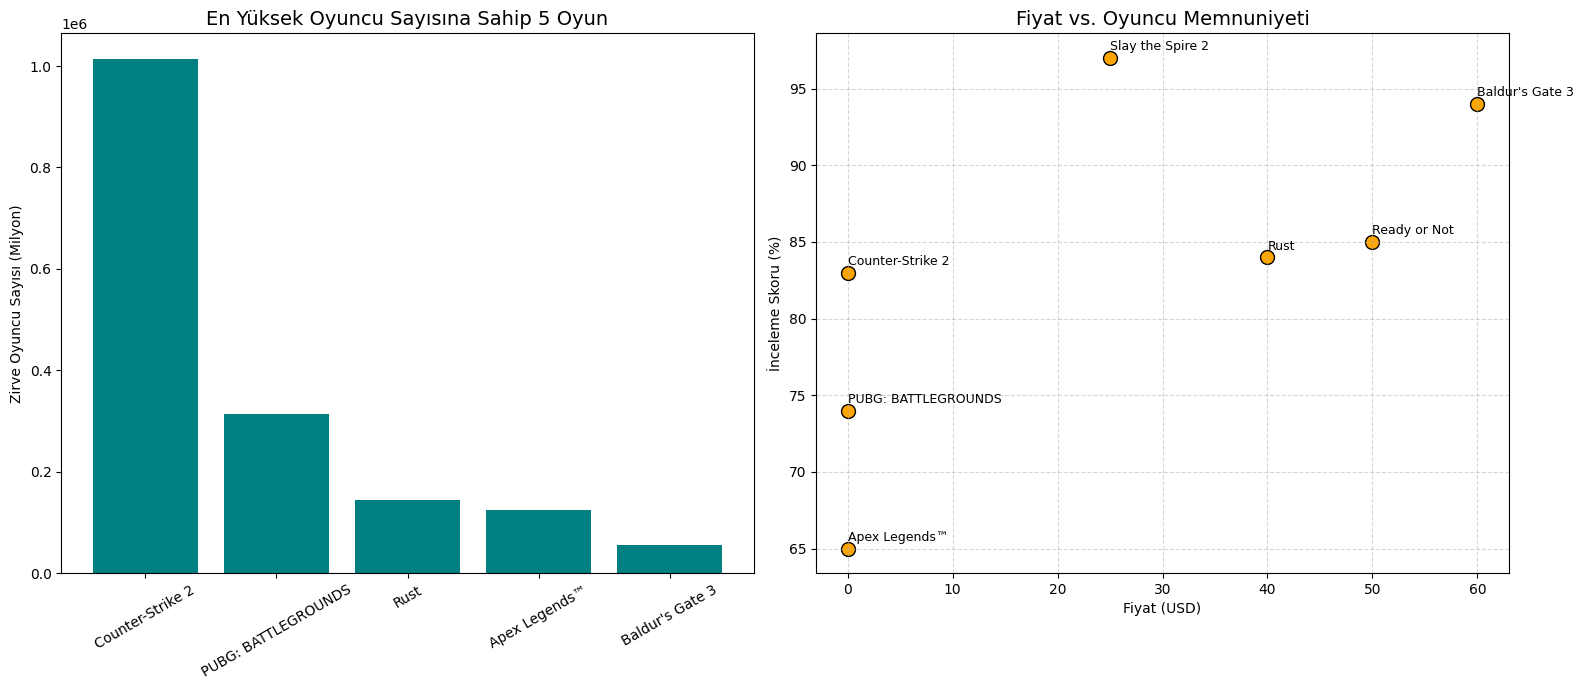

--- Veri Seti Özeti ---
Toplam Oyun Sayısı: 8
Ortalama Fiyat: 30.62 USD
En Yüksek Skor: %97 ile Slay the Spire 2


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. VERİ SETİNİN OLUŞTURULMASI
data = """AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
730,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer,0.0,0,83,4980365,Unknown,149410950,1013936
2868840,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike,24.99,0,97,49549,Unknown,1486470,0
3321460,Crimson Desert,2026-03-19,Action,Action;Open World,69.99,0,0,0,Unknown,0,0
1144200,Ready or Not,2023-12-13,Action,Tactical;Realistic,49.99,0,85,243810,Unknown,7314300,4296
1172470,Apex Legends™,2020-11-04,Action,Free to Play;Multiplayer,0.0,0,65,1577,Unknown,47310,124262
252490,Rust,2018-02-08,Action,Survival;Crafting,39.99,0,84,1116689,Unknown,33500670,143870
578080,PUBG: BATTLEGROUNDS,2017-12-21,Action,Survival;Shooter,0.0,0,74,1757549,Unknown,52726470,314682
1086940,Baldur's Gate 3,2023-08-03,Adventure,RPG;Turn-Based,59.99,0,94,730296,Unknown,21908880,54771
"""

# CSV formatındaki metni Pandas DataFrame'e çeviriyoruz
df = pd.read_csv(io.StringIO(data))

# 2. VERİ TEMİZLEME VE FİLTRELEME
# Henüz çıkmamış veya puanı/oyuncusu olmayanları analiz için ayıklayalım
df_active = df[df['Review_Score_Pct'] > 0].copy()

# 3. GÖRSELLEŞTİRME (Çift Grafik Paneli)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- SOL GRAFİK: Oyuncu Sayısı Analizi ---
top_players = df.nlargest(5, '24h_Peak_Players')
ax1.bar(top_players['Name'], top_players['24h_Peak_Players'], color='teal')
ax1.set_title('En Yüksek Oyuncu Sayısına Sahip 5 Oyun', fontsize=14)
ax1.set_ylabel('Zirve Oyuncu Sayısı (Milyon)')
ax1.tick_params(axis='x', rotation=30)

# --- SAĞ GRAFİK: Fiyat ve İnceleme Skoru İlişkisi ---
ax2.scatter(df_active['Price_USD'], df_active['Review_Score_Pct'], s=100, color='orange', edgecolors='black')
for i, txt in enumerate(df_active['Name']):
    ax2.annotate(txt, (df_active['Price_USD'].iloc[i], df_active['Review_Score_Pct'].iloc[i] + 0.5), fontsize=9)

ax2.set_title('Fiyat vs. Oyuncu Memnuniyeti', fontsize=14)
ax2.set_xlabel('Fiyat (USD)')
ax2.set_ylabel('İnceleme Skoru (%)')
ax2.grid(True, linestyle='--', alpha=0.5)

# Grafiklerin birbirine girmemesi için düzenle ve göster
plt.tight_layout()
plt.show()

# 4. ÖZET İSTATİSTİKLER (Konsol Çıktısı)
print("--- Veri Seti Özeti ---")
print(f"Toplam Oyun Sayısı: {len(df)}")
print(f"Ortalama Fiyat: {df['Price_USD'].mean():.2f} USD")
print(f"En Yüksek Skor: %{df['Review_Score_Pct'].max()} ile {df.loc[df['Review_Score_Pct'].idxmax(), 'Name']}")